Sistema de Detección de Fraude Híbrido (Tabular + NLP)
------------------------------------------------------
Este script entrena y despliega un modelo de ensamblado (Stacking) que combina:
1. XGBoost: Para análisis de datos estructurados (tabulares).
2. DistilBERT + Keras NN: Para análisis de texto (descripciones de siniestros).
3. Meta-Learner (Keras): Para combinar las predicciones de ambos modelos.
Incluye una interfaz gráfica generada con ipywidgets para pruebas en tiempo real.


In [ ]:
import numpy as np
import tensorflow as tf
import random
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, f1_score, roc_curve
from sklearn.utils import class_weight

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from google.colab import drive
import torch
from transformers import AutoTokenizer, AutoModel

In [ ]:
# ==============================================================================
# CONFIGURACIÓN INICIAL Y REPRODUCIBILIDAD
# ==============================================================================
def set_random_seed(seed_value):
    """
    Fija las semillas generadoras de números aleatorios para garantizar
    la reproducibilidad de los resultados en múltiples ejecuciones.

    Args:
        seed_value (int): Valor de la semilla a utilizar.
    """
    np.random.seed(seed_value)
    tf.random.set_seed(seed_value)
    torch.manual_seed(seed_value)
    random.seed(seed_value)
    print(f"[*] Semillas aleatorias fijadas en {seed_value}.")

set_random_seed(42)
plt.style.use('ggplot')


[*] Semillas aleatorias fijadas en 42.


In [ ]:
# ==============================================================================
# 1. CARGA Y PREPARACIÓN DE DATOS TABULARES
# ==============================================================================
print("\n[*] 1. Cargando datos...")
drive.mount('/content/drive/')
file_path = '/content/drive/My Drive/Data/dataset_reclamos_ia_ruidoso_extremo.xlsx'

df = pd.read_excel(file_path)

print("[*] Feature Engineering Tabular...")
# Conversión de columnas de fecha a objetos datetime
date_cols = ['Incident_Date', 'Date_Reported', 'Policy_Start_Date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Creación de nuevas variables predictoras basadas en tiempo
# Report_Delay: cantidad de días transcurridos entre la fecha de reporte del siniestro y la fecha del siniestro
df['Report_Delay'] = (df['Date_Reported'] - df['Incident_Date']).dt.days.fillna(0)
# Days_Since_Policy: cantidad de días transcurridos entre la fecha del siniestro y el inicio de vigencia de la póliza
df['Days_Since_Policy'] = (df['Incident_Date'] - df['Policy_Start_Date']).dt.days.fillna(0)
max_model_year = df['Model_Year'].max()
# Car_Age: Edad del vehículo respecto a la cartera de vehículos asegurados
df['Car_Age'] = max_model_year - df['Model_Year']

# Eliminación de columnas no útiles para el modelo
df = df.select_dtypes(exclude=['datetime64'])
df = df.drop(columns=['Claim_ID', 'Policy_Number', 'Last_Purchase_History_Date'], errors='ignore')

# Codificación de variables categóricas a valores numéricos
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    if col != 'Claim_Description':  # Excluimos el texto libre
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

# Separación de características (X) y variable objetivo (y)
X_tab_df = df.drop(columns=['Claim_Description', 'Prediccion_Fraude'])
X_tab_features = X_tab_df.columns.tolist()
X_tab = X_tab_df.values
y = df['Prediccion_Fraude'].values
text_data = df['Claim_Description'].astype(str).tolist()



[*] 1. Cargando datos...
Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
[*] Feature Engineering Tabular...


In [ ]:
# ==============================================================================
# 2. PROCESAMIENTO NLP CON PYTORCH Y DISTILBERT (FEATURE EXTRACTION)
# ==============================================================================
print("\n[*] 2. Descargando modelo DistilBERT Nativo (PyTorch)...")

# Carga del tokenizador y modelo pre-entrenado
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-multilingual-cased")
distilbert_model = AutoModel.from_pretrained("distilbert-base-multilingual-cased")

# Modo evaluación: apaga Dropout/BatchNorm ya que no re-entrenaremos DistilBERT
distilbert_model.eval()

# Asignación a GPU para acelerar la inferencia si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
distilbert_model.to(device)
print(f"[*] Usando dispositivo: {device}")

def extract_embeddings(text_list, batch_size=32):
    """
    Convierte una lista de textos en embeddings densos usando DistilBERT.

    Args:
        text_list (list): Lista de cadenas de texto (descripciones).
        batch_size (int): Tamaño del lote para procesar en memoria.

    Returns:
        np.ndarray: Matriz de dimensiones (N_textos, 768) con los embeddings.
    """
    all_embeddings = []
    for i in range(0, len(text_list), batch_size):
        batch = text_list[i:i+batch_size]
        # Tokenización con truncamiento y padding dinámico
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=120, return_tensors="pt").to(device)

        # torch.no_grad() reduce el consumo de memoria VRAM al no calcular gradientes
        with torch.no_grad():
            outputs = distilbert_model(**inputs)

        # Extracción del token [CLS] (índice 0) que actúa como resumen semántico de la oración
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)

    return np.vstack(all_embeddings)

print("[*] Convirtiendo todos los textos a Embeddings de DistilBERT (Esto tomará unos segundos)...")
X_text_embeddings = extract_embeddings(text_data)
print(f"[*] Embeddings generados con forma: {X_text_embeddings.shape} (Textos, Dimensiones)")



[*] 2. Descargando modelo DistilBERT Nativo (PyTorch)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Usando dispositivo: cuda
[*] Convirtiendo todos los textos a Embeddings de DistilBERT (Esto tomará unos segundos)...
[*] Embeddings generados con forma: (5000, 768) (Textos, Dimensiones)


In [ ]:
# ==============================================================================
# 3. DIVISION DE DATOS: TRAIN, VALIDATION, META Y TEST
# ==============================================================================
print("\n[*] 3. Dividiendo datos de forma estratificada...")

# División en 4 conjuntos manteniendo la proporción de clases (stratify)
indices = np.arange(len(y))
idx_temp, idx_test, y_temp, y_test = train_test_split(indices, y, test_size=0.20, random_state=42, stratify=y)
idx_base, idx_meta, y_base, y_meta = train_test_split(idx_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)
idx_train, idx_val, y_train, y_val = train_test_split(idx_base, y_base, test_size=0.20, random_state=42, stratify=y_base)

# Asignación de divisiones a los datos tabulares
X_tab_train, X_tab_val, X_tab_meta, X_tab_test = X_tab[idx_train], X_tab[idx_val], X_tab[idx_meta], X_tab[idx_test]

# Asignación de divisiones a los datos de texto (Embeddings)
X_text_train = X_text_embeddings[idx_train]
X_text_val   = X_text_embeddings[idx_val]
X_text_meta  = X_text_embeddings[idx_meta]
X_text_test  = X_text_embeddings[idx_test]



[*] 3. Dividiendo datos de forma estratificada...


In [ ]:
# ==============================================================================
# FUNCIONES DE EVALUACIÓN
# ==============================================================================
def evaluate_and_plot_metrics(y_true, y_pred_prob, model_name, threshold=0.5, history=None):
    """
    Calcula métricas de clasificación y genera gráficos (Matriz de Confusión y Curva ROC).
    Opcionalmente, grafica la evolución del accuracy y loss durante el entrenamiento
    si se proporciona un objeto history de Keras.

    Args:
        y_true (array): Etiquetas reales.
        y_pred_prob (array): Probabilidades predichas por el modelo.
        model_name (str): Nombre del modelo evaluado (para títulos de gráficos).
        threshold (float): Umbral para convertir probabilidad en clase binaria.
        history (tensorflow.keras.callbacks.History, optional): Objeto History de Keras
                                                            que contiene los registros de entrenamiento.
    """
    y_pred_bin = (y_pred_prob > threshold).astype(int)
    print(f"\n" + "="*60 + f"\n📈 EVALUACIÓN EN TEST SET: {model_name}\n" + "="*60)
    print(f"F1-Score: {f1_score(y_true, y_pred_bin):.4f} | AUC-ROC: {roc_auc_score(y_true, y_pred_prob):.4f}\n")
    print(classification_report(y_true, y_pred_bin, target_names=['Normal', 'Fraude']))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Matriz de confusión
    sns.heatmap(confusion_matrix(y_true, y_pred_bin), annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title(f'Matriz Confusión - {model_name}')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc_score(y_true, y_pred_prob):.4f}')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_title(f'Curva ROC - {model_name}')
    axes[1].legend(loc="lower right")
    plt.show()

    if history:
        # Gráficos de Accuracy y Loss
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        # Plot training & validation accuracy values
        ax1.plot(history.history['accuracy'])
        ax1.plot(history.history['val_accuracy'])
        ax1.set_title(f'Accuracy del Modelo {model_name}')
        ax1.set_ylabel('Accuracy')
        ax1.set_xlabel('Epoch')
        ax1.legend(['Train', 'Validation'], loc='upper left')

        # Plot training & validation loss values
        ax2.plot(history.history['loss'])
        ax2.plot(history.history['val_loss'])
        ax2.set_title(f'Loss del Modelo {model_name}')
        ax2.set_ylabel('Loss')
        ax2.set_xlabel('Epoch')
        ax2.legend(['Train', 'Validation'], loc='upper left')
        plt.show()



🧠 ENTRENANDO XGBoost (Tabular)...
[0]	validation_0-logloss:0.66591	validation_0-error:0.10500	validation_1-logloss:0.66977	validation_1-error:0.14833
[1]	validation_0-logloss:0.64061	validation_0-error:0.08708	validation_1-logloss:0.64797	validation_1-error:0.13500
[2]	validation_0-logloss:0.61784	validation_0-error:0.08583	validation_1-logloss:0.62822	validation_1-error:0.13333
[3]	validation_0-logloss:0.59842	validation_0-error:0.08917	validation_1-logloss:0.61142	validation_1-error:0.13833
[4]	validation_0-logloss:0.58051	validation_0-error:0.08167	validation_1-logloss:0.59568	validation_1-error:0.13000
[5]	validation_0-logloss:0.56386	validation_0-error:0.08583	validation_1-logloss:0.58116	validation_1-error:0.13167
[6]	validation_0-logloss:0.54789	validation_0-error:0.08542	validation_1-logloss:0.56787	validation_1-error:0.13333
[7]	validation_0-logloss:0.53297	validation_0-error:0.07833	validation_1-logloss:0.55445	validation_1-error:0.11167
[8]	validation_0-logloss:0.51949	vali

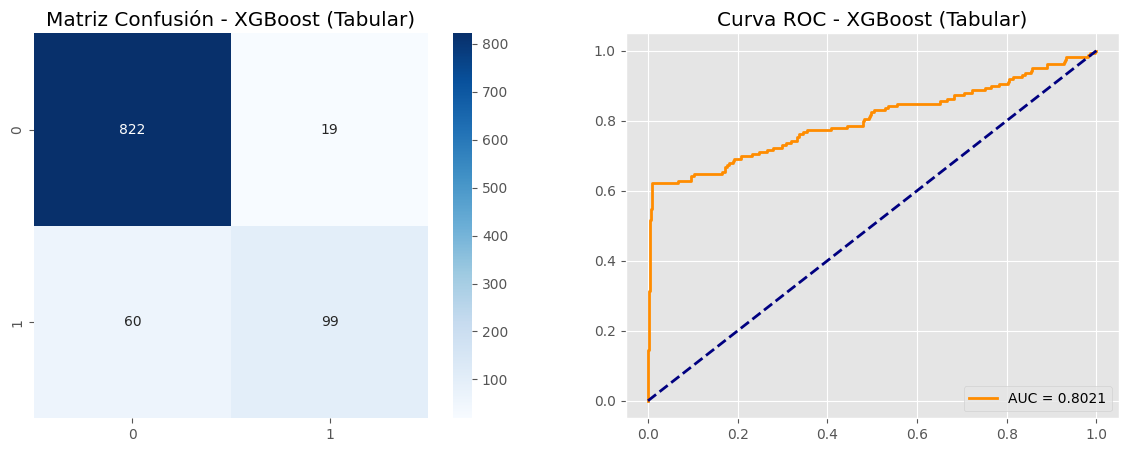

In [ ]:
# ==============================================================================
# 4. MODELO 1: XGBOOST (DATOS TABULARES)
# ==============================================================================
print("\n🧠 ENTRENANDO XGBoost (Tabular)...")
# scale_pos_weight ayuda a XGBoost a penalizar más los errores en la clase minoritaria (fraude)
xgb_model = xgb.XGBClassifier(
    n_estimators=100, learning_rate=0.05, max_depth=6,
    scale_pos_weight=float(np.sum(y_train==0)/np.sum(y_train==1)),
    eval_metric=["logloss", "error"]
)
model_tab = xgb_model.fit(X_tab_train, y_train, eval_set=[(X_tab_train, y_train), (X_tab_val, y_val)], verbose=True)
evaluate_and_plot_metrics(y_test, xgb_model.predict_proba(X_tab_test)[:, 1], "XGBoost (Tabular)")



🧠 ENTRENANDO RED NEURONAL (Sobre Embeddings de DistilBERT)...
Epoch 1/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9488 - loss: 0.1544 - val_accuracy: 1.0000 - val_loss: 7.2082e-04
Epoch 2/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0086 - val_accuracy: 1.0000 - val_loss: 5.0559e-05
Epoch 3/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9996 - loss: 0.0031 - val_accuracy: 1.0000 - val_loss: 8.6842e-06
Epoch 4/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9996 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 2.5963e-06
Epoch 5/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9992 - loss: 0.0032 - val_accuracy: 1.0000 - val_loss: 5.0474e-06
Epoch 6/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 6.8549e-04 - val_accuracy: 1.0000 - val_loss: 1.0507e-06
Epoch 7/25
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 8.0654e-04 - val_accuracy: 1.0000 - val_loss: 4.3037e-07
Epoch 8/25
75/75 ━

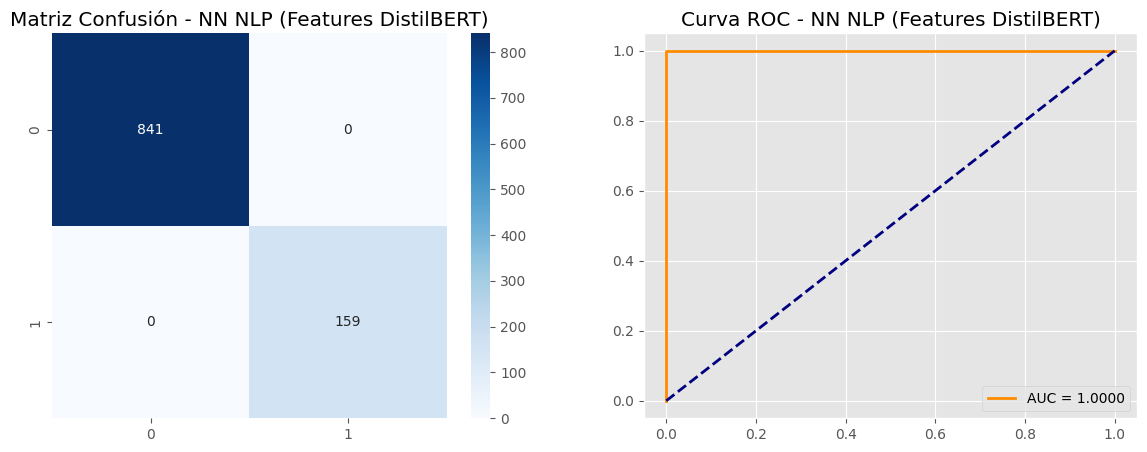

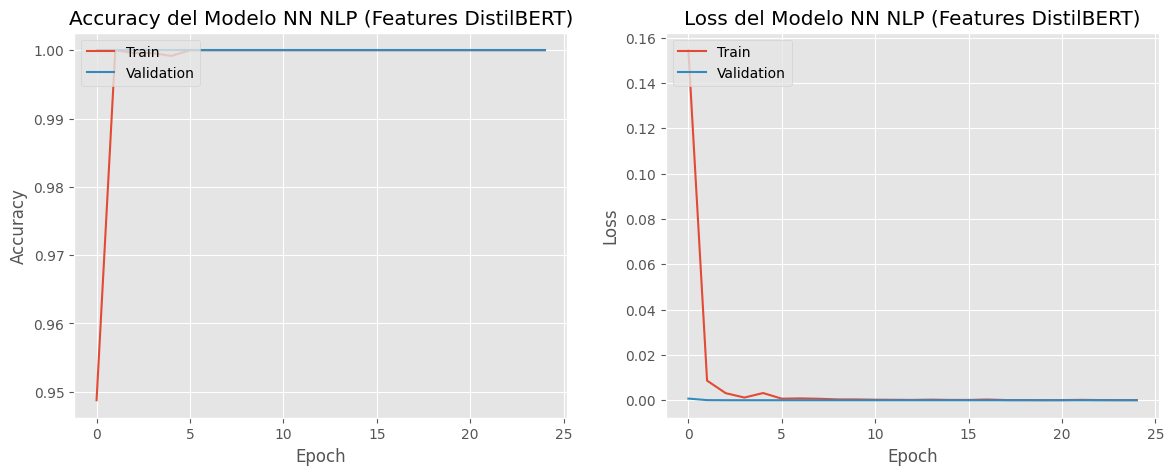

In [ ]:
# ==============================================================================
# 5. MODELO 2: RED NEURONAL DE KERAS (Recibiendo Embeddings)
# ==============================================================================
print("\n🧠 ENTRENANDO RED NEURONAL (Sobre Embeddings de DistilBERT)...")

# Arquitectura densa para clasificar los vectores de 768 dimensiones
input_text = Input(shape=(768,), name="text_embedding_input")
x = Dense(128, activation='relu')(input_text)
x = Dropout(0.5)(x) # Previene el sobreajuste (overfitting)
x = Dense(32, activation='relu')(x)
x = Dropout(0.4)(x)
output_text = Dense(1, activation='sigmoid')(x)

nn_text_model = Model(inputs=input_text, outputs=output_text)
nn_text_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Detiene el entrenamiento si no hay mejora en validación para evitar overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

# Cálculo de pesos para lidiar con el desbalance de clases
class_weights_dict = dict(enumerate(class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)))

# Entrenamiento rápido (los embeddings pesados ya fueron pre-calculados)
history_nn = nn_text_model.fit(
    X_text_train, y_train,
    validation_data=(X_text_val, y_val),
    epochs=25, batch_size=32,
    class_weight=class_weights_dict, callbacks=[early_stopping], verbose=1
)

evaluate_and_plot_metrics(y_test, nn_text_model.predict(X_text_test, verbose=0).flatten(), "NN NLP (Features DistilBERT)", history=history_nn)



🧠 ENTRENANDO MODELO HÍBRIDO (META-LEARNER)...
Epoch 1/17
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.1338 - loss: 0.7728 - val_accuracy: 0.2100 - val_loss: 0.7364
Epoch 2/17
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2962 - loss: 0.7282 - val_accuracy: 0.4000 - val_loss: 0.6997
Epoch 3/17
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5412 - loss: 0.6928 - val_accuracy: 0.6450 - val_loss: 0.6704
Epoch 4/17
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7262 - loss: 0.6646 - val_accuracy: 0.7950 - val_loss: 0.6465
Epoch 5/17
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8413 - loss: 0.6417 - val_accuracy: 0.8950 - val_loss: 0.6265
Epoch 6/17
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9062 - loss: 0.6220 - val_accuracy: 0.9350 - val_loss: 0.6087
Epoch 7/17
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9287 - loss: 0.6040 - val_accuracy: 0.9400 - val_loss: 0.5918
Epoch 8/17
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9350 -

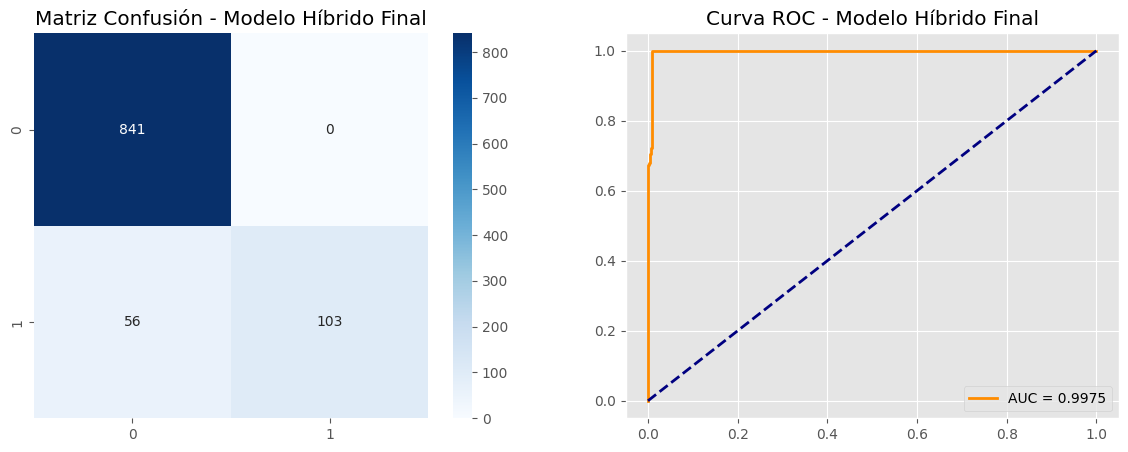

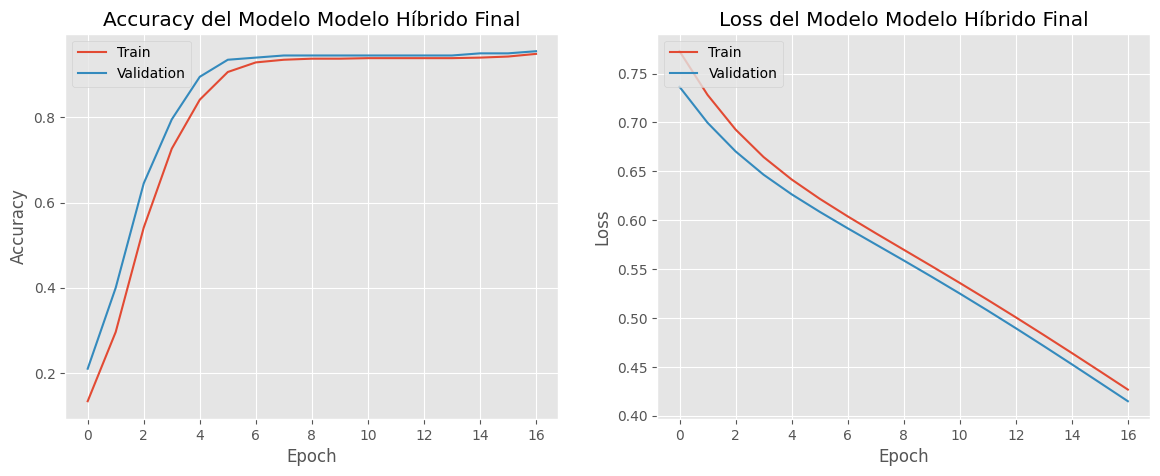

In [ ]:
# ==============================================================================
# 6. MODELO 3: META-LEARNER (STACKING ENSEMBLE)
# ==============================================================================
print("\n🧠 ENTRENANDO MODELO HÍBRIDO (META-LEARNER)...")

# Generación de predicciones Out-of-Fold para entrenar el Meta-Learner
pred_meta_xgb = xgb_model.predict_proba(X_tab_meta)[:, 1]
pred_meta_nn = nn_text_model.predict(X_text_meta, verbose=0).flatten()

# Arquitectura del Meta-Learner (Red pequeña que toma las 2 probabilidades como entrada)
meta_input = Input(shape=(2,), name="meta_input")
x = Dense(8, activation='relu')(meta_input)
meta_output = Dense(1, activation='sigmoid')(x)

meta_nn = Model(inputs=meta_input, outputs=meta_output)
meta_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenamiento del ensamble
history_meta_nn = meta_nn.fit(
    np.column_stack((pred_meta_xgb, pred_meta_nn)),
    y_meta,
    validation_split=0.2,
    epochs=17, #30
    verbose=1
)

def predecir_fraude_stacking(X_tab_nuevo, texto_nuevo_str):
    """
    Ejecuta el pipeline completo de predicción para datos nuevos.

    Args:
        X_tab_nuevo (array): Datos tabulares preprocesados.
        texto_nuevo_str (list): Lista con el texto crudo de la descripción.

    Returns:
        tuple: (Probabilidad global del ensemble, prob. XGBoost, prob. NN de texto)
    """
    p1 = xgb_model.predict_proba(X_tab_nuevo)[:, 1]

    # Extracción en vivo del embedding y predicción
    emb_nuevo = extract_embeddings(texto_nuevo_str)
    p2 = nn_text_model.predict(emb_nuevo, verbose=0).flatten()

    meta_in = np.column_stack((p1, p2))
    return meta_nn.predict(meta_in, verbose=0).flatten(), p1[0], p2[0]

pred_test_stacking, _, _ = predecir_fraude_stacking(X_tab_test, df['Claim_Description'].iloc[idx_test].tolist())
evaluate_and_plot_metrics(y_test, pred_test_stacking, "Modelo Híbrido Final", history=history_meta_nn)


In [ ]:
# ==============================================================================
# 7. INTERFAZ GRÁFICA (UI)
# ==============================================================================
print("\n--- CARGANDO INTERFAZ DE PREDICCIÓN CON DISTILBERT ---")

# Construcción de widgets dinámicos basados en las características del modelo
engineered_cols = ['Report_Delay', 'Days_Since_Policy', 'Car_Age']
categorical_cols = list(label_encoders.keys())
numerical_cols = [col for col in X_tab_features if col not in categorical_cols and col not in engineered_cols]

input_widgets = {}
style = {'description_width': '150px'}
layout = widgets.Layout(width='400px', margin='0 0 5px 0')

# Generación de campos de entrada por tipo de dato
for col in date_cols: input_widgets[col] = widgets.DatePicker(description=col.replace('_', ' '), value=datetime.date.today(), style=style, layout=layout)
for col in numerical_cols: input_widgets[col] = widgets.FloatText(description=col.replace('_', ' '), value=0.0, style=style, layout=layout)
for col in categorical_cols: input_widgets[col] = widgets.Dropdown(description=col.replace('_', ' '), options=list(label_encoders[col].classes_), style=style, layout=layout)
input_widgets['Claim_Description'] = widgets.Textarea(value='Colisión en intersección.', description='Descripción:', style=style, layout=widgets.Layout(width='820px', height='100px'))

# Organización visual en pestañas (Tabs)
tab_fechas = widgets.VBox([input_widgets[c] for c in date_cols])
tab_numeros = widgets.VBox([input_widgets[c] for c in numerical_cols])
cat_mid = len(categorical_cols) // 2
tab_categorias = widgets.HBox([widgets.VBox([input_widgets[c] for c in categorical_cols[:cat_mid]]), widgets.VBox([input_widgets[c] for c in categorical_cols[cat_mid:]])])
tabs = widgets.Tab(children=[tab_fechas, tab_numeros, tab_categorias])
tabs.set_title(0, 'Fechas'); tabs.set_title(1, 'Números'); tabs.set_title(2, 'Categorías')

predict_button = widgets.Button(description='🔍 Evaluar Siniestro', button_style='danger', layout=widgets.Layout(width='300px', height='50px', margin='20px 0 0 0'))
output_area = widgets.Output()

display(HTML("<h3>Sistema Detección Fraude (Stacking: XGBoost + DistilBERT/PyTorch)</h3>"))
display(tabs, input_widgets['Claim_Description'], predict_button, output_area)

def on_predict_button_clicked(b):
    """
    Callback que se ejecuta al presionar el botón 'Evaluar Siniestro'.
    Recopila los datos de los widgets, los preprocesa y llama a la función de predicción.
    """
    with output_area:
        clear_output(wait=True)
        print("Analizando variables tabulares e infiriendo contexto lingüístico con DistilBERT...")

        # Extracción y estructuración de los datos del formulario
        raw_data = {key: widget.value for key, widget in input_widgets.items() if key != 'Claim_Description'}
        input_df = pd.DataFrame([raw_data])

        # Preprocesamiento idéntico al entrenamiento
        for col in date_cols: input_df[col] = pd.to_datetime(input_df[col])
        input_df['Report_Delay'] = (input_df['Date_Reported'] - input_df['Incident_Date']).dt.days.fillna(0)
        input_df['Days_Since_Policy'] = (input_df['Incident_Date'] - input_df['Policy_Start_Date']).dt.days.fillna(0)
        input_df['Car_Age'] = max_model_year - input_df['Model_Year'] if 'Model_Year' in input_df.columns else 0

        for col, le in label_encoders.items():
            if col in input_df.columns: input_df[col] = le.transform(input_df[col].astype(str))

        X_tab_new = input_df[X_tab_features].values
        texto_crudo = [input_widgets['Claim_Description'].value]

        # Inferencia
        prob_stack, prob_xgb, prob_nn = predecir_fraude_stacking(X_tab_new, texto_crudo)

        # Despliegue de resultados
        display(HTML("<hr>"))
        color, icon = ('red', '⚠️ ALERTA') if prob_stack > 0.5 else ('green', '✅ APROBADO')
        display(HTML(f"<h2 style='color:{color};'>{icon}: Probabilidad Global de Fraude: {prob_stack[0]*100:.2f}%</h2>"))
        print(f" -> Modelo Tabular (XGBoost) indica: {prob_xgb*100:.2f}%")
        print(f" -> Modelo NLP (DistilBERT) indica: {prob_nn*100:.2f}%")

predict_button.on_click(on_predict_button_clicked)


--- CARGANDO INTERFAZ DE PREDICCIÓN CON DISTILBERT ---


Textarea(value='Colisión en intersección.', description='Descripción:', layout=Layout(height='100px', width='8…

Button(button_style='danger', description='🔍 Evaluar Siniestro', layout=Layout(height='50px', margin='20px 0 0…

Output()